<h1 align='center' style='color:purple'>Clustering With K Means - Python Tutorial</h1>

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

ModuleNotFoundError: No module named 'sklearn'

In [2]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income($)')

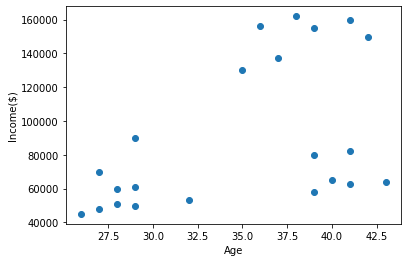

In [3]:
plt.scatter(df.Age,df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')

In [7]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income($)']])
y_predicted

array([0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2])

In [8]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


In [9]:
km.cluster_centers_

array([[3.40000000e+01, 8.05000000e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.29090909e+01, 5.61363636e+04]])

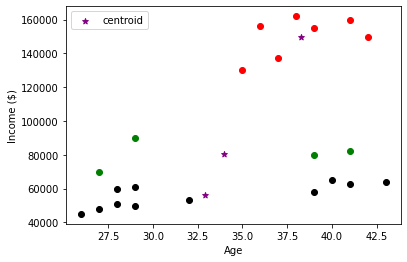

In [10]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend()

<h4 style='color:purple'>Preprocessing using min max scaler</h4>

In [11]:
scaler = MinMaxScaler()

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [12]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1


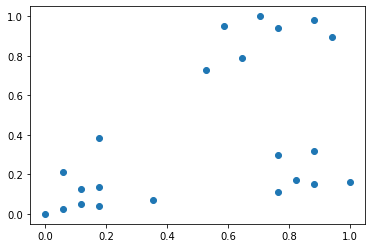

In [13]:
plt.scatter(df.Age,df['Income($)'])

In [14]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income($)']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2])

In [15]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [16]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

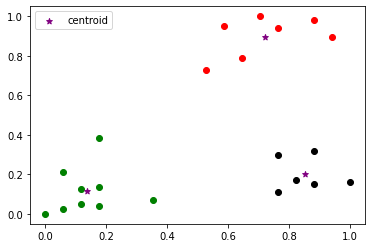

In [17]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

<h4 style='color:purple'>Elbow Plot</h4>

In [18]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

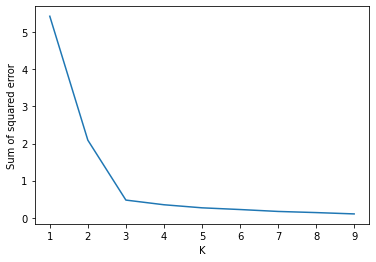

In [19]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
Defines an empty list sse to store the sum of squared errors (SSE) for each value of k.
Defines a range k_rng for the number of clusters k from 1 to 9.
For each value of k, it initializes a KMeans object with n_clusters set to k.
Fits the KMeans model to the dataframe df containing columns Age and Income($).
Appends the inertia (SSE) of the fitted model to the sse list.

Data Creation:

A simple dataset with Age and Income($) columns is created using a dictionary and converted to a DataFrame.
KMeans Clustering:

The loop iterates over a range of k values (from 1 to 9).
For each k, a KMeans object is created and fitted to the df[['Age', 'Income($)']] data.
The inertia (SSE) of the fitted model is appended to the sse list.
Elbow Method Plot:

The plot visualizes the SSE values for different k values.
The "elbow" point on the graph indicates the optimal number of clusters where the SSE starts to decrease more slowly.

In the context of the KMeans clustering algorithm, inertia is a measure of how well the data points are clustered around the centroids. It is also known as the sum of squared errors (SSE) or within-cluster sum of squares (WCSS). Inertia quantifies the sum of the squared distances between each data point and the nearest centroid.

In simpler terms, inertia indicates how tight the clusters are. Lower inertia means that the data points are closer to their respective cluster centroids, which typically indicates better clustering.

km.inertia_ represents the sum of squared distances of samples to their closest cluster center. This value is computed for each k (number of clusters) in the range of 1 to 9. These inertia values are then stored in the sse list and plotted to help determine the optimal number of clusters using the Elbow Method.

Elbow Method
The Elbow Method is used to determine the optimal number of clusters by plotting the inertia values against the number of clusters. The "elbow" point in the plot, where the rate of decrease of inertia sharply slows down, indicates the optimal number of clusters. This point balances the trade-off between having fewer clusters (and thus higher inertia) and having too many clusters (which may lead to overfitting and unnecessarily complex models).

By minimizing inertia, we aim to create clusters where the data points are as close as possible to their respective centroids, indicating tight and well-formed clusters.

<h4 style='color:purple'>Exercise</h4>

<img src='iris.png' width=200 height=200>

1. Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features. Drop other two features for simplicity.
2. Figure out if any preprocessing such as scaling would help here
3. Draw elbow plot and from that figure out optimal value of k